In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("../data/adult3.csv")
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (48842, 15)


In [ ]:
#Understanding the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [5]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
df.describe(include="object")

,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
count,48842,48842,48842,48842,48842,48842,48842,48842,48842
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


In [7]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [ ]:
#Check the target variable distribution
df["income"].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [9]:
df["income"].value_counts(normalize=True) * 100

income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64

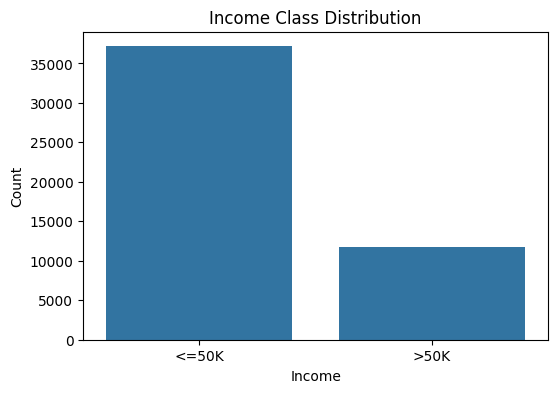

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="income")

plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()

In [11]:
df = df.replace("?", np.nan)

In [12]:
df.isnull().sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [ ]:
#Define X and y
X = df.drop("income", axis=1)
y = df["income"]

In [14]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (48842, 14)
Target: (48842,)


In [ ]:
#Identify numerical and categorical features
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


In [ ]:
#Train/test split with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y
)

In [ ]:
#Numerical Preprocessing Pipeline
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [ ]:
#Categorical Preprocessing Pipeline
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [ ]:
#Combination of numerical and categorical preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
#defining models to be used for training

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    
    "KNN": KNeighborsClassifier(),
    
    "SVM": SVC(),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [ ]:
#Training and comparing models
results = []

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            pos_label=">50K"
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            pos_label=">50K"
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            pos_label=">50K"
        )
    })

In [ ]:
#Displaying the results of different models in a DataFrame and sorting by F1 Score
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
4,Gradient Boosting,0.867643,0.797044,0.599658,0.684403
1,Random Forest,0.859453,0.740169,0.636014,0.684150
3,SVM,0.859556,0.768931,0.590676,0.668118
0,Logistic Regression,0.852390,0.741379,0.588537,0.656175
2,KNN,0.833657,0.668081,0.606074,0.635569


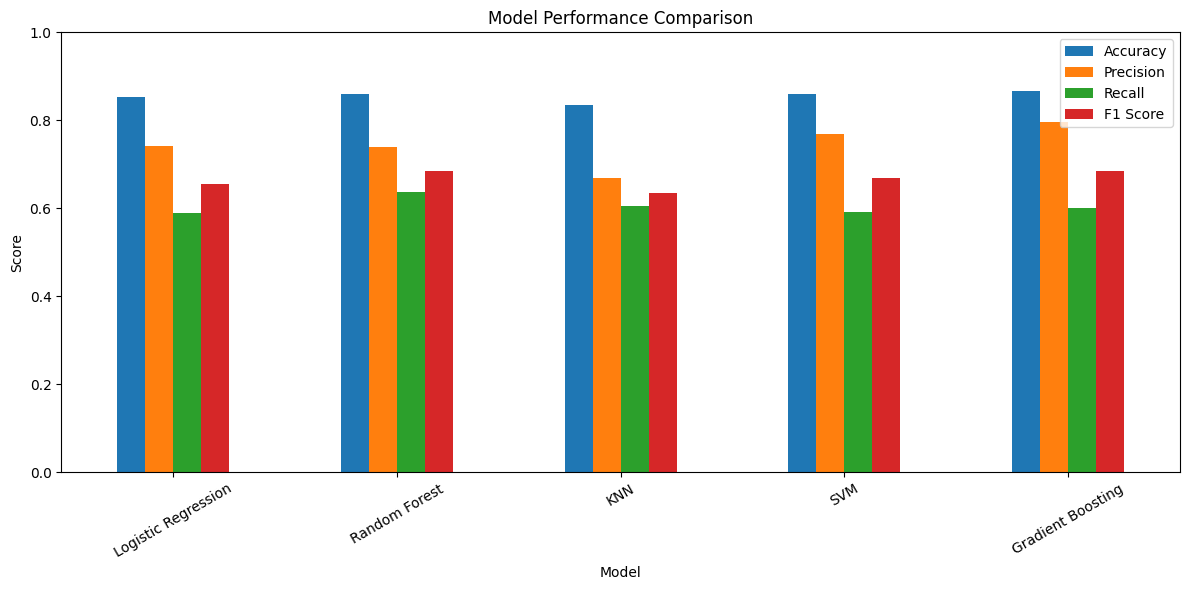

In [27]:
#Visualise model comparison results
results_plot = results_df.set_index("Model")

results_plot[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=30)
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
#Selecting the final model
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("Selected model:", best_model_name)

Selected model: Gradient Boosting


In [29]:
best_model = models[best_model_name]

In [31]:
#Build final pipeline with the best model and train it
final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", best_model)
    ]
)
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'educational-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'gender',
                                                   'native-country'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [33]:
#Final Evaluation on the test set
y_pred = final_pipeline.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(
          y_test,
          y_pred,
          pos_label=">50K"
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred,
          pos_label=">50K"
      ))

print("F1 Score:",
      f1_score(
          y_test,
          y_pred,
          pos_label=">50K"
      ))

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.86764254273723
Precision: 0.7970437748720864
Recall: 0.5996578272027374
F1 Score: 0.6844032218696607
              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.92      7431
        >50K       0.80      0.60      0.68      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.78      0.80      9769
weighted avg       0.86      0.87      0.86      9769



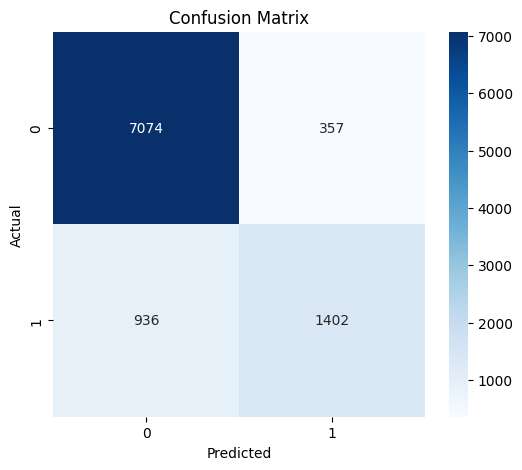

In [34]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [42]:
# saving the entire pipeline including preprocessing and the best model
import os
import joblib

os.makedirs("../model", exist_ok=True)

joblib.dump(
    final_pipeline,
    "../model/salary_prediction_pipeline.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [43]:
#Testing the saved model
loaded_model = joblib.load(
    "../model/salary_prediction_model.pkl"
)

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Prediction:", prediction[0])
print("Actual:", y_test.iloc[0])

Prediction: <=50K
Actual: <=50K


In [ ]:
#Testing the probability of the prediction
probability = loaded_model.predict_proba(sample)

print(probability)
print(loaded_model.classes_)

[[0.8299457 0.1700543]]
['<=50K' '>50K']


In [ ]:
#Testing the probability of the prediction
for class_name, prob in zip(
    loaded_model.classes_,
    probability[0]
):
    print(f"{class_name}: {prob:.2%}")

<=50K: 82.99%
>50K: 17.01%
